In [ ]:
# Read a PT file


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# Load the .pt file
image_tensor = torch.load('../data/input_image.pt')

entropy_tensor = torch.load('../data/entropy.pt')

image_array = image_tensor.numpy()
entropy_array = entropy_tensor.numpy()

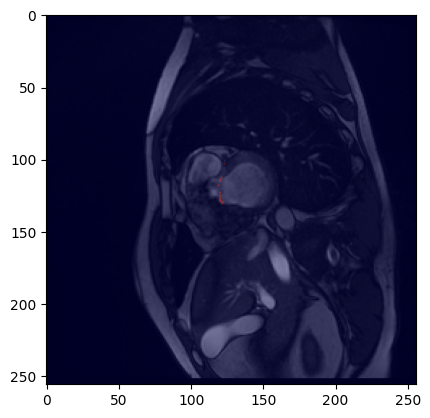

In [13]:
# Overlay the image with the entropy
def threshold_and_overlay(threshold ,image = image_array, entropy= entropy_array):
    thresholded_entropy = np.where(entropy > threshold, entropy, 0)
    plt.imshow(image, cmap='gray')
    plt.imshow(thresholded_entropy, cmap='seismic', alpha=0.5)
    plt.show()


threshold_and_overlay(0.9)

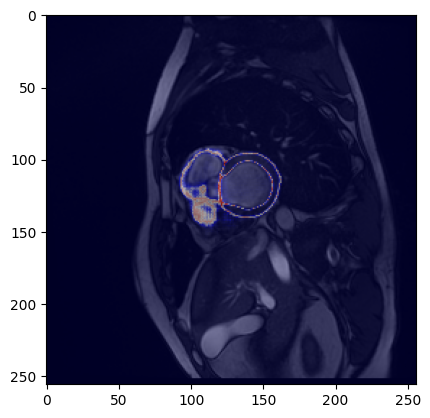

In [ ]:


plt.imshow(image_array, cmap='gray')
plt.imshow(entropy_array, cmap='seismic', alpha=0.5)
plt.show()


In [112]:
entropy_array.max()

np.float32(1.1944067)

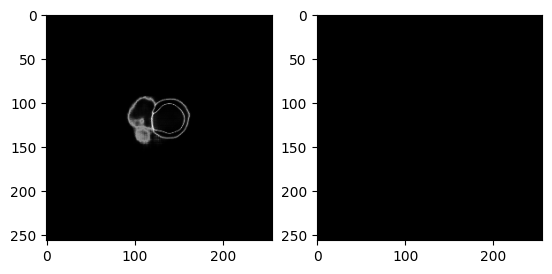

In [121]:
# keep only the high entropy regions

threshold = 2.0
mask = entropy_array > threshold
filtered_entropy = mask * entropy_array

fig, ax = plt.subplots(1, 2)
ax[0].imshow(entropy_array, cmap='gray')
ax[1].imshow(filtered_entropy, cmap='gray')
plt.show()


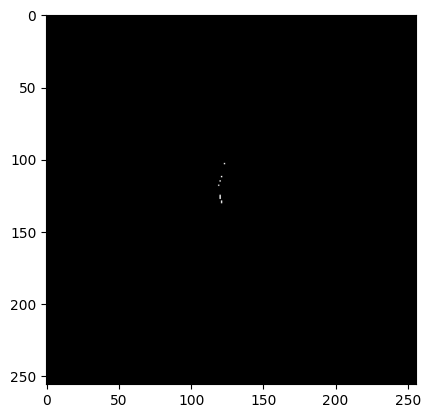

In [123]:
img = np.where(entropy_array > 1.0, entropy_array, 0)
plt.imshow(img, cmap='gray')

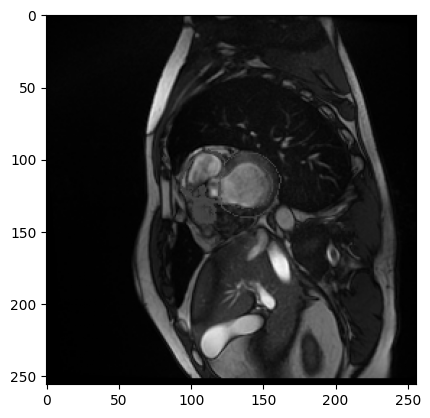

In [124]:
res = np.where(entropy_array > 0.5, entropy_array, image_array)
plt.imshow(res, cmap='gray')
plt.show()

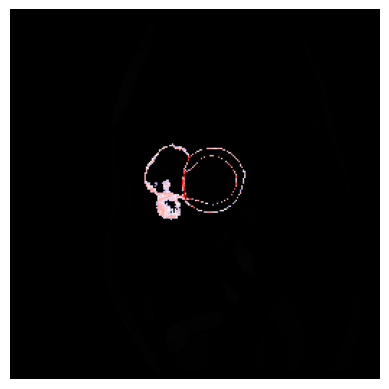

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm



# Normalize entropy array for colormap mapping
norm_entropy = (entropy_array - entropy_array.min()) / (entropy_array.max() - entropy_array.min())

# Create a mask
mask = entropy_array > 0.5

# Convert to colormaps
seismic_mapped = cm.seismic(norm_entropy)  # RGBA (0-1 range)
gray_mapped = cm.gray(image_array / 255)   # Normalize image_array and apply grayscale

# Combine: Use seismic where mask is True, otherwise use gray
colored_output = np.where(mask[..., None], seismic_mapped, gray_mapped)

# Display the image
plt.imshow(colored_output)
plt.axis('off')
plt.show()


In [131]:
image_array.max()

np.float32(4.5043225)

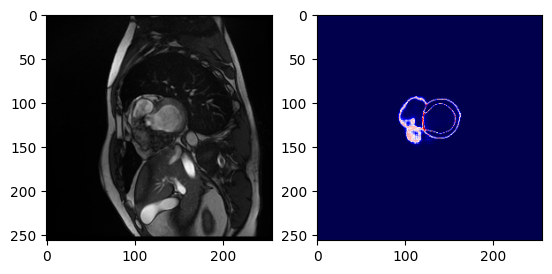

In [ ]:
# Plot image and entropy side by side
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image_array, cmap='gray')
ax[1].imshow(entropy_array, cmap='seismic')
plt.show()

## Dataframe

In [1]:
import pandas as pd

df = pd.read_csv('../dataframe.csv')
df.head()

,batch_index,image_index,avg_error,avg_entropy
0,9,24,0.404800,0.049940
1,9,23,0.397461,0.052719
2,9,26,0.366791,0.050594
3,9,25,0.358978,0.043790
4,9,27,0.352875,0.037998


In [6]:
int(df.iloc[0]['batch_index'])

9

In [8]:
# get image of batch 9 and image 24 from dataframe
batch_index = 9
image_index = 24


result = df[(df["batch_index"] == batch_index) & (df["image_index"] == image_index)]

In [12]:
result['avg_entropy'].values[0]

np.float64(0.0499401055)

In [ ]:
# sort the dataframe by ascending entropy
df_sorted = df.sort_values(by='entropy', ascending=True)

In [16]:
type([(3,4)][0])

tuple